# Save 1d light curve into a single file in data_LC/1d

## Utility
### - 天体名対応辞書作成

In [1]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 20
#   hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit') # MacBook
  hdu=fits.open('/home/kazuma/Workspace/Fermi/gll_psc_v35.fit') # Legion
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  
  
  sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_cls_converted = str(sources_blazars_cls).strip()

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj

### 使い方

In [2]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str18,str28,str5,int64
4fgl_j2253.9+1609,3c_454.3,FSRQ,1
4fgl_j1104.4+3812,mkn_421,BLL,2
4fgl_j2202.7+4216,bl_lac,BLL,3
4fgl_j2232.6+1143,cta_102,FSRQ,4
4fgl_j1256.1-0547,3c_279,FSRQ,5
4fgl_j0721.9+7120,s5_0716+71,BLL,6
4fgl_j1427.9-4206,pks_1424-41,FSRQ,7
4fgl_j0428.6-3756,pks_0426-380,bll,8
4fgl_j0538.8-4405,pks_0537-441,BLL,9


Rewrite the assoc name

In [3]:
dict_sourcename[0]['assoc name']  = '3C454.3' 
dict_sourcename[1]['assoc name']  = 'Mrk421' 
dict_sourcename[2]['assoc name']  = 'BLLac' 
dict_sourcename[3]['assoc name']  = 'CTA102' 
dict_sourcename[4]['assoc name']  = '3C279'
dict_sourcename[5]['assoc name']  = 'S50716+71' 
dict_sourcename[6]['assoc name']  = 'PKS1424-41' 
dict_sourcename[7]['assoc name']  = 'PKS0426-380'
dict_sourcename[8]['assoc name']  = 'PKS0537-441'
dict_sourcename[9]['assoc name']  = 'PKS2155-304'
dict_sourcename[10]['assoc name'] = 'PKS0454-234'
dict_sourcename[11]['assoc name'] = 'PKS1510-089'
dict_sourcename[12]['assoc name'] = 'PKS1502+106'
dict_sourcename[13]['assoc name'] = 'TON599'
dict_sourcename[14]['assoc name'] = 'PKS0346-27'
dict_sourcename[15]['assoc name'] = '4c+01.02'
dict_sourcename[16]['assoc name'] = '4c+55.17'
dict_sourcename[17]['assoc name'] = '4c+21.35'
dict_sourcename[18]['assoc name'] = 'PKS1830-211'
dict_sourcename[19]['assoc name'] = 'PKS0208-512'
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str18,str28,str5,int64
4fgl_j2253.9+1609,3C454.3,FSRQ,1
4fgl_j1104.4+3812,Mrk421,BLL,2
4fgl_j2202.7+4216,BLLac,BLL,3
4fgl_j2232.6+1143,CTA102,FSRQ,4
4fgl_j1256.1-0547,3C279,FSRQ,5
4fgl_j0721.9+7120,S50716+71,BLL,6
4fgl_j1427.9-4206,PKS1424-41,FSRQ,7
4fgl_j0428.6-3756,PKS0426-380,bll,8
4fgl_j0538.8-4405,PKS0537-441,BLL,9


# LC directories

In [4]:
import os

def get_lc_files_14d(dir_path_lc= "./data_LC/14d"): 
    filenames= [
        f for f in os.listdir(dir_path_lc) if os.path.isfile(os.path.join(dir_path_lc, f))
    ]
    # print(filenames)
    return filenames


64
109
<Table length=896>
         name          dtype  shape unit n_bad
--------------------- ------- ----- ---- -----
                 tmin float64          s     0
                 tmax float64          s     0
             tmin_mjd float64          d     0
             tmax_mjd float64          d     0
        loglike_const float64                3
           flux_const float64                3
          fit_success    bool                0
    fit_success_fixed    bool                0
           fit_status   int64                0
          fit_quality   int64                0
      num_free_params   int64                0
          param_names bytes32 (10,)          0
    param_names_fixed bytes32 (10,)          0
         param_values float64 (10,)       4495
   param_values_fixed float64 (10,)       4495
         param_errors float64 (10,)       6341
   param_errors_fixed float64 (10,)       8067
                   ts float64                3
             ts_fixed float64     

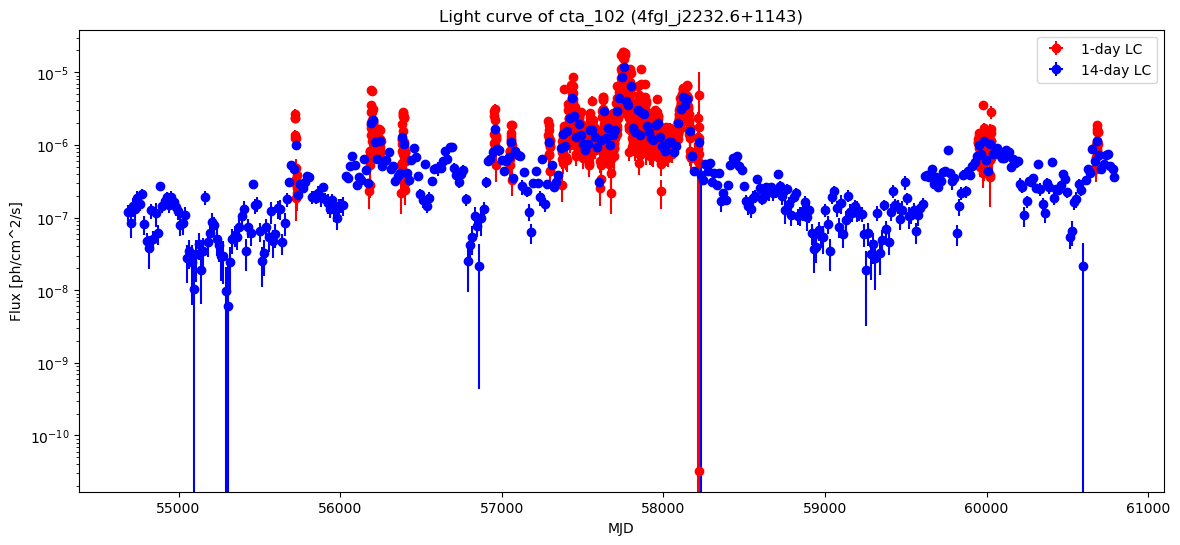

In [7]:
# source_number=0
# lc_dir_1d_parentpath='/home/kazuma/Workspace/AGN_data/051_3C454_1d'
# source_number=2
# lc_dir_1d_parentpath='/home/kazuma/Workspace/AGN_data/053_BLLac_1d'
source_number=3
lc_dir_1d_parentpath='/home/kazuma/Workspace/AGN_data/054_CTA102_1d'

dict_sourcename = get_dict_sourcenames()
# print(dict_sourcename)
# print(dict_sourcename[source_number])
# print(dict_sourcename[source_number]['4FGL name'])
# print(dict_sourcename[source_number]['assoc name'])
# print(dict_sourcename[source_number]['index'])
source = dict_sourcename[source_number]
#########################################
#  14day light curve
#########################################
from astropy.table import Table, vstack
table_14dLC = Table.read(os.path.join('./data_LC/14d', source['4FGL name'] + '_lightcurve.fits'))
table_14dLC.add_column((table_14dLC['tmax_mjd'] + table_14dLC['tmin_mjd']) / 2., name='t_mjd', index=0)

#########################################
#  1day light curve
#########################################
ana_subdirectories=os.listdir(lc_dir_1d_parentpath)
print(len(ana_subdirectories))
# print(ana_subdirectories[0])
from astropy.table import Table, vstack
table_allLCs=Table()
for ana_subdirectory in ana_subdirectories:
    # sed_parentdirectory = os.path.join(lc_dir_1d_parentpath, ana_subdirectory,'1days')
    # sed_subdirectories = os.listdir(sed_parentdirectory)
    # print(f"Number of SED subdirectories: {len(sed_subdirectories)}")

    lc_tab = Table.read(os.path.join(lc_dir_1d_parentpath,ana_subdirectory, source['4FGL name'] + '_lightcurve.fits'))
    table_allLCs = vstack([table_allLCs, lc_tab])

print(len(table_allLCs.columns))
print(table_allLCs.info)
print(table_allLCs)
table_allLCs.write(os.path.join('./data_LC/1d', source['4FGL name'] + '_lightcurve_all.fits'), overwrite=True)
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

table_allLCs.add_column((table_allLCs['tmax_mjd'] + table_allLCs['tmin_mjd']) / 2., name='t_mjd', index=0)
lc_x=table_allLCs['t_mjd']
lc_y=table_allLCs['flux']
lc_xerr=np.ones(len(lc_x))*7.0
lc_yerr=table_allLCs['flux_err']
# plt.plot(lc_x,lc_y ,marker='o', linestyle='',color= 'red', label=source['assoc name'])
plt.errorbar(lc_x, lc_y, xerr=lc_xerr, yerr=lc_yerr, fmt='o', color='red', label='1-day LC')
lc_x=table_14dLC['t_mjd']
lc_y=table_14dLC['flux']
lc_xerr=np.ones(len(lc_x))*1.0
lc_yerr=table_14dLC['flux_err']
# plt.plot(lc_x,lc_y ,marker='o', linestyle='',color= 'blue', label=source['assoc name'])
plt.errorbar(lc_x, lc_y, xerr=lc_xerr, yerr=lc_yerr, fmt='o', color='blue', label='14-day LC')
plt.xlabel('MJD')
plt.ylabel('Flux [ph/cm^2/s]')
plt.yscale('log')
plt.title(f"Light curve of {source['assoc name']} ({source['4FGL name']})")
plt.legend()
plt.savefig(os.path.join('./figures', 'lightcurve_1d_' + str(source_number+1) + '_' + source['assoc name'] + '_'  + source['4FGL name'] + '.png'))